# LangGraph Subgraphs with Shared State + TTS Output

This notebook demonstrates:
- A **parent graph** that generates an English answer to a question
- A **subgraph** that translates the answer to Marathi
- A **TTS node** that converts both answers to speech using gTTS
- In-notebook audio playback via `IPython.display.Audio`

In [1]:
# Install gTTS if not already installed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "gTTS", "-q"])
print("gTTS ready")

gTTS ready


In [40]:
from typing_extensions import TypedDict
from typing import Optional
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
import io
from gtts import gTTS
from IPython.display import Markdown, Audio, display

In [3]:
load_dotenv()

True

## State Definition

Added `audio_eng` and `audio_hin` fields to carry the TTS audio bytes through the graph.

In [4]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str
    audio_eng: Optional[bytes]   # MP3 bytes for English TTS
    audio_hin: Optional[bytes]   # MP3 bytes for Marathi TTS

In [5]:
parent_llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=os.getenv("LLM_API_KEY"))
subgraph_llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=os.getenv("LLM_API_KEY"))

## Subgraph: Translation (English → Marathi)

In [6]:
def translate_text(state: ParentState):
    prompt = f"""
    Translate the following text to Marathi.
    Keep it natural and clear. Do not add extra content.

    TEXT:{state["answer_eng"]}
    """.strip()

    translated_text = subgraph_llm.invoke(prompt).content
    return {"answer_hin": translated_text}

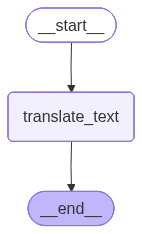

In [7]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node("translate_text", translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()
subgraph

## Parent Graph Nodes

In [8]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(
        f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}"
    ).content
    return {"answer_eng": answer}

## TTS Node

Converts both the English and Marathi answers to speech using **gTTS**.
Audio is stored as in-memory MP3 bytes in the graph state.

- `lang='en'` for English
- `lang='mr'` for Marathi

> **Note:** gTTS requires an internet connection to call the Google Text-to-Speech API.

In [12]:
def text_to_speech(state: ParentState) -> dict:
    """Convert English and Marathi answers to speech (MP3 bytes)."""

    def synthesize(text: str, lang: str) -> bytes:
        """Use gTTS to synthesize text and return raw MP3 bytes."""
        # Strip markdown formatting so TTS doesn't read asterisks/hashes
        import re
        clean = re.sub(r'[#*`=\-]{2,}', '', text)   # remove **, ##, ==, -- etc.
        clean = re.sub(r'[#*`]', '', clean)           # remove remaining #, *, `
        clean = re.sub(r'\n{2,}', '.\n', clean)       # collapse blank lines
        clean = clean.strip()

        buf = io.BytesIO()
        tts = gTTS(text=clean, lang=lang, slow=False)
        tts.write_to_fp(buf)
        buf.seek(0)
        return buf.read()

    # print("Generating English TTS...")
    # audio_eng = synthesize(state["answer_eng"], lang="en")

    print("Generating Marathi TTS...")
    audio_hin = synthesize(state["answer_hin"], lang="mr")

    print("TTS generation complete.")
    return {"audio_hin": audio_hin}

## Build the Parent Graph

Flow: `answer` → `translate` (subgraph) → `tts` → END

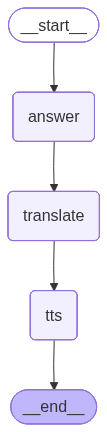

In [13]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)
parent_builder.add_node("tts", text_to_speech)

parent_builder.add_edge(START, "answer")
parent_builder.add_edge("answer", "translate")
parent_builder.add_edge("translate", "tts")
parent_builder.add_edge("tts", END)

graph = parent_builder.compile()
graph

## Run the Graph

In [34]:
result = graph.invoke({"question": "What is Machine Learning"})
print("Graph execution complete.")

Generating Marathi TTS...
TTS generation complete.
Graph execution complete.


## Display Results

In [35]:
# English Answer (text)
display(Markdown("### English Answer"))
display(Markdown(result["answer_eng"]))

### English Answer

**Machine Learning (ML)** is a subset of Artificial Intelligence (AI) that involves training algorithms to learn from data and make predictions or decisions without being explicitly programmed.

**Key aspects of Machine Learning:**

1. **Data**: ML relies on large amounts of data to learn patterns, relationships, and trends.
2. **Algorithms**: ML uses various algorithms, such as linear regression, decision trees, and neural networks, to analyze the data.
3. **Training**: The algorithm is trained on the data, allowing it to learn and improve its performance over time.
4. **Prediction**: The trained algorithm can make predictions or decisions based on new, unseen data.

**Types of Machine Learning:**

1. **Supervised Learning**: The algorithm is trained on labeled data to learn the relationship between input and output.
2. **Unsupervised Learning**: The algorithm is trained on unlabeled data to discover patterns and relationships.
3. **Reinforcement Learning**: The algorithm learns through trial and error by interacting with an environment.

**Applications of Machine Learning:**

1. **Image and Speech Recognition**
2. **Natural Language Processing**
3. **Predictive Maintenance**
4. **Recommendation Systems**
5. **Autonomous Vehicles**

**In summary**, Machine Learning is a powerful technology that enables computers to learn from data and make intelligent decisions, with applications across various industries and domains.

In [36]:
# Marathi Answer (text)
display(Markdown("### Marathi Translation (मराठी)"))
display(Markdown(result["answer_hin"]))

### Marathi Translation (मराठी)

**मशीन लर्निंग (ML)** हा आर्टिफिशियल इंटेलिजेंस (AI) चा एक उपसमूह आहे ज्यामध्ये अल्गोरिदमचे प्रशिक्षण दिले जाते ज्यामुळे ते डेटा वरून शिकण्याची क्रिया करू शकतात आणि स्पष्टपणे प्रोग्राम केले नसले तरीही अंदाज किंवा निर्णय घेऊ शकतात.

**मशीन लर्निंगची मुख्य विशेषता**

1. **डेटा**: एमएल ला पॅटर्न, संबंध आणि प्रवृत्ती शिकण्यासाठी मोठ्या प्रमाणात डेटाची गरज असते.
2. **अल्गोरिदम**: एमएलमध्ये डेटा विश्लेषण करण्यासाठी लीनियर रिग्रेशन, डिसिजन ट्री, आणि न्यूरल नेटवर्क यासारखे विविध अल्गोरिदम वापरले जातात.
3. **प्रशिक्षण**: अल्गोरिदमला डेटावर प्रशिक्षण दिले जाते, ज्यामुळे ते शिकू शकते आणि वेळेबरोबर त्याची कार्यक्षमता सुधारते.
4. **अंदाज**: प्रशिक्षित अल्गोरिदम नवीन, अनदेखील डेटावर आधारित अंदाज किंवा निर्णय घेऊ शकते.

**मशीन लर्निंगचे प्रकार**

1. **सुपरवाइझ्ड लर्निंग**: अल्गोरिदमला इनपुट आणि आउटपुट यांच्यातील संबंध शिकण्यासाठी लेबल केलेल्या डेटावर प्रशिक्षण दिले जाते.
2. **अनसुपरवाइझ्ड लर्निंग**: अल्गोरिदमला पॅटर्न आणि संबंध शोधण्यासाठी अनलेबल्ड डेटावर प्रशिक्षण दिले जाते.
3. **रिन्फोर्समेंट लर्निंग**: अल्गोरिदम परीक्षण आणि त्रुटी द्वारे परिस्थितीशी संवाद साधून शिकते.

**मशीन लर्निंगचे उपयोग**

1. **इमेज आणि स्पीच रिकग्निशन**
2. **नॅचरल लँग्वेज प्रोसेसिंग**
3. **प्रेडिक्टिव मेंटेनन्स**
4. **रेकमेंडेशन सिस्टम**
5. **ऑटोनॉमस वेहिकल्स**

**सारांश**, मशीन लर्निंग ही एक शक्तिशाली तंत्रज्ञान आहे जी संगणकाला डेटा वरून शिकण्याची आणि बुद्धिमान निर्णय घेण्याची क्रिया करण्याची परवानगी देते, ज्याचे विविध उद्योग आणि क्षेत्रांमध्ये अनेक उपयोग आहेत.

In [38]:
# Marathi Answer (audio)
display(Markdown("### Marathi Answer — Audio (मराठी)"))
display(Audio(data=result["audio_hin"], autoplay=False))

### Marathi Answer — Audio (मराठी)

In [39]:
with open("answer_marathi.mp3", "wb") as f:
    f.write(result["audio_hin"])
print("Audio files saved: answer_marathi.mp3")

Audio files saved: answer_marathi.mp3
